In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
import string
import numpy as np
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import GridSearchCV, cross_val_score
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from scipy.sparse import hstack, csr_matrix
from collections import Counter
import joblib
from sklearn.metrics import (
    ConfusionMatrixDisplay, confusion_matrix, classification_report,
    roc_curve, auc, precision_recall_curve,accuracy_score, f1_score
)

In [2]:
!pip install vaderSentiment

In [3]:
df = pd.read_csv("twitter_disaster.csv")

In [4]:
df.head()

,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1


In [5]:
df.shape

(7613, 5)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7613 entries, 0 to 7612
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        7613 non-null   int64 
 1   keyword   7552 non-null   object
 2   location  5080 non-null   object
 3   text      7613 non-null   object
 4   target    7613 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 297.5+ KB


In [7]:
df.isnull().sum()

id             0
keyword       61
location    2533
text           0
target         0
dtype: int64

In [8]:
df['keyword'] = df['keyword'].fillna('none')
df['location'] = df['location'].fillna('unknown')

In [9]:
df.isnull().sum()

id          0
keyword     0
location    0
text        0
target      0
dtype: int64

In [10]:
df.head(50)

,id,keyword,location,text,target
0,1,none,unknown,Our Deeds are the Reason of this #earthquake M...,1
1,4,none,unknown,Forest fire near La Ronge Sask. Canada,1
2,5,none,unknown,All residents asked to 'shelter in place' are ...,1
3,6,none,unknown,"13,000 people receive #wildfires evacuation or...",1
4,7,none,unknown,Just got sent this photo from Ruby #Alaska as ...,1
5,8,none,unknown,#RockyFire Update => California Hwy. 20 closed...,1
6,10,none,unknown,#flood #disaster Heavy rain causes flash flood...,1
7,13,none,unknown,I'm on top of the hill and I can see a fire in...,1
8,14,none,unknown,There's an emergency evacuation happening now ...,1
9,15,none,unknown,I'm afraid that the tornado is coming to our a...,1


In [11]:
df.duplicated().sum()

np.int64(0)


Class distribution (0=non-disaster, 1=disaster):
 target
0    4342
1    3271
Name: count, dtype: int64


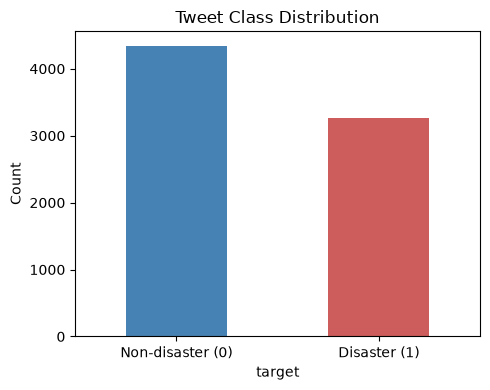

In [12]:
class_counts = df["target"].value_counts().sort_index()
print("\nClass distribution (0=non-disaster, 1=disaster):\n", class_counts)
 
plt.figure(figsize=(5, 4))
class_counts.plot(kind="bar", color=["steelblue", "indianred"])
plt.xticks([0, 1], ["Non-disaster (0)", "Disaster (1)"], rotation=0)
plt.title("Tweet Class Distribution")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [13]:
URL_RE = re.compile(r"https?://\S+|www\.\S+")
HTML_RE = re.compile(r"<.*?>")
MENTION_RE = re.compile(r"@\w+")
NON_ALPHA_RE = re.compile(r"[^a-zA-Z\s]")
 
 
def clean_text(text: str) -> str:
    """Lowercase, strip URLs/HTML/mentions/punctuation/digits, collapse whitespace."""
    text = str(text).lower()
    text = URL_RE.sub(" ", text)
    text = HTML_RE.sub(" ", text)
    text = MENTION_RE.sub(" ", text)
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = NON_ALPHA_RE.sub(" ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

In [14]:
df["clean_text"] = df["text"].apply(clean_text)
display(df[["text", "clean_text"]])

,text,clean_text
0,Our Deeds are the Reason of this #earthquake M...,our deeds are the reason of this earthquake ma...
1,Forest fire near La Ronge Sask. Canada,forest fire near la ronge sask canada
2,All residents asked to 'shelter in place' are ...,all residents asked to shelter in place are be...
3,"13,000 people receive #wildfires evacuation or...",people receive wildfires evacuation orders in ...
4,Just got sent this photo from Ruby #Alaska as ...,just got sent this photo from ruby alaska as s...
...,...,...
7608,Two giant cranes holding a bridge collapse int...,two giant cranes holding a bridge collapse int...
7609,@aria_ahrary @TheTawniest The out of control w...,the out of control wild fires in california ev...
7610,M1.94 [01:04 UTC]?5km S of Volcano Hawaii. htt...,m utc km s of volcano hawaii
7611,Police investigating after an e-bike collided ...,police investigating after an ebike collided w...


In [15]:
nltk.download("punkt")
nltk.download("stopwords")
nltk.download("wordnet")

STOPWORDS = set(stopwords.words("english"))
LEMMATIZER = WordNetLemmatizer()

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\vincy\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\vincy\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\vincy\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [16]:
def tokenize_and_lemmatize(text: str) -> list[str]:
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in STOPWORDS and len(t) > 1]
    tokens = [LEMMATIZER.lemmatize(t) for t in tokens]
    return tokens

df["tokens"] = df["clean_text"].apply(tokenize_and_lemmatize)
display(df[["clean_text", "tokens"]])

,clean_text,tokens
0,our deeds are the reason of this earthquake ma...,"[deed, reason, earthquake, may, allah, forgive..."
1,forest fire near la ronge sask canada,"[forest, fire, near, la, ronge, sask, canada]"
2,all residents asked to shelter in place are be...,"[resident, asked, shelter, place, notified, of..."
3,people receive wildfires evacuation orders in ...,"[people, receive, wildfire, evacuation, order,..."
4,just got sent this photo from ruby alaska as s...,"[got, sent, photo, ruby, alaska, smoke, wildfi..."
...,...,...
7608,two giant cranes holding a bridge collapse int...,"[two, giant, crane, holding, bridge, collapse,..."
7609,the out of control wild fires in california ev...,"[control, wild, fire, california, even, northe..."
7610,m utc km s of volcano hawaii,"[utc, km, volcano, hawaii]"
7611,police investigating after an ebike collided w...,"[police, investigating, ebike, collided, car, ..."


In [17]:
df["tokens_str"] = df["tokens"].apply(lambda toks: " ".join(toks))
display(df[["tokens", "tokens_str"]])

,tokens,tokens_str
0,"[deed, reason, earthquake, may, allah, forgive...",deed reason earthquake may allah forgive u
1,"[forest, fire, near, la, ronge, sask, canada]",forest fire near la ronge sask canada
2,"[resident, asked, shelter, place, notified, of...",resident asked shelter place notified officer ...
3,"[people, receive, wildfire, evacuation, order,...",people receive wildfire evacuation order calif...
4,"[got, sent, photo, ruby, alaska, smoke, wildfi...",got sent photo ruby alaska smoke wildfire pour...
...,...,...
7608,"[two, giant, crane, holding, bridge, collapse,...",two giant crane holding bridge collapse nearby...
7609,"[control, wild, fire, california, even, northe...",control wild fire california even northern par...
7610,"[utc, km, volcano, hawaii]",utc km volcano hawaii
7611,"[police, investigating, ebike, collided, car, ...",police investigating ebike collided car little...


In [18]:
df["tweet_length"] = df["text"].apply(len)
df["word_count"] = df["tokens"].apply(len)
df["has_hashtag"] = df["text"].str.contains(r"#\w+", regex=True).astype(int)
df["has_mention"] = df["text"].str.contains(r"@\w+", regex=True).astype(int)
 
display(df[["text", "clean_text", "tokens_str"]].head())

,text,clean_text,tokens_str
0,Our Deeds are the Reason of this #earthquake M...,our deeds are the reason of this earthquake ma...,deed reason earthquake may allah forgive u
1,Forest fire near La Ronge Sask. Canada,forest fire near la ronge sask canada,forest fire near la ronge sask canada
2,All residents asked to 'shelter in place' are ...,all residents asked to shelter in place are be...,resident asked shelter place notified officer ...
3,"13,000 people receive #wildfires evacuation or...",people receive wildfires evacuation orders in ...,people receive wildfire evacuation order calif...
4,Just got sent this photo from Ruby #Alaska as ...,just got sent this photo from ruby alaska as s...,got sent photo ruby alaska smoke wildfire pour...


In [19]:
for label, name in [(1, "Disaster"), (0, "Non-disaster")]:
    words = Counter(w for toks in df.loc[df["target"] == label, "tokens"] for w in toks)
    print(f"\nTop 15 words — {name}:")
    for word, count in words.most_common(15):
        print(f"  {word}: {count}")


Top 15 words — Disaster:
  fire: 265
  news: 144
  via: 121
  disaster: 118
  california: 115
  suicide: 110
  amp: 109
  police: 107
  people: 106
  family: 105
  home: 101
  train: 100
  building: 95
  killed: 93
  like: 92

Top 15 words — Non-disaster:
  like: 255
  im: 244
  amp: 193
  get: 185
  new: 171
  dont: 141
  one: 137
  body: 117
  time: 104
  video: 102
  via: 99
  day: 98
  would: 97
  love: 95
  go: 92


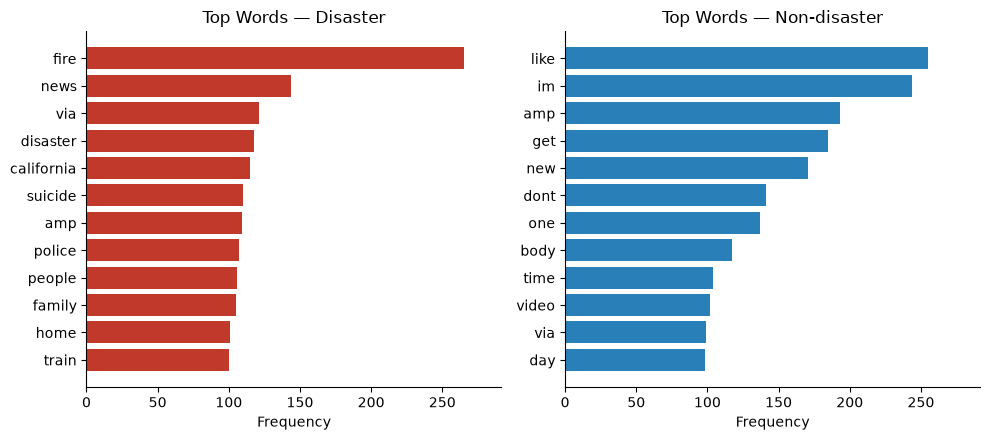

In [20]:
COLOR_DISASTER = "#c0392b" 
COLOR_NONDISASTER = "#2980b9" 
tokens_disaster = df.loc[df["target"] == 1, "tokens_str"].str.split().sum()
tokens_non = df.loc[df["target"] == 0, "tokens_str"].str.split().sum()
top_disaster = pd.DataFrame(Counter(tokens_disaster).most_common(12), columns=["word", "freq"])
top_non = pd.DataFrame(Counter(tokens_non).most_common(12), columns=["word", "freq"])
max_freq = max(top_disaster["freq"].max(), top_non["freq"].max())
 
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), sharex=True)
axes[0].barh(top_disaster["word"][::-1], top_disaster["freq"][::-1], color=COLOR_DISASTER)
axes[0].set_title("Top Words — Disaster")
axes[1].barh(top_non["word"][::-1], top_non["freq"][::-1], color=COLOR_NONDISASTER)
axes[1].set_title("Top Words — Non-disaster")
for ax in axes:
    ax.set_xlim(0, max_freq * 1.1)
    ax.set_xlabel("Frequency")
    sns.despine(ax=ax)
plt.tight_layout()
plt.show()

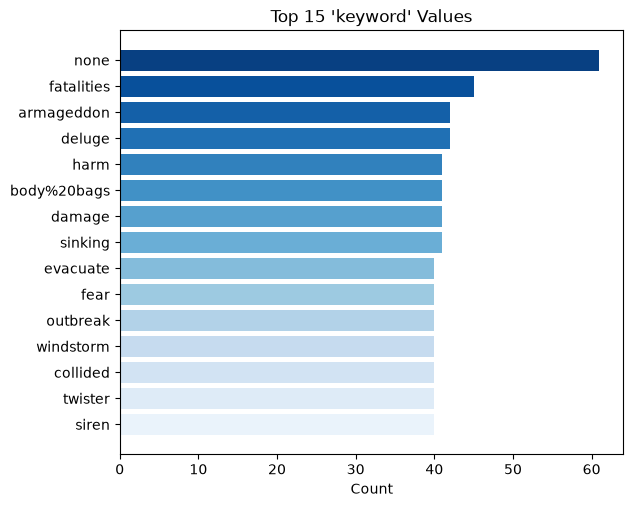

In [21]:
CMAP_SEQ = "Blues"
top_keywords = df["keyword"].value_counts().head(15).sort_values()
plt.figure(figsize=(6.5, 5.5))
colors = sns.color_palette(CMAP_SEQ, n_colors=len(top_keywords))
plt.barh(top_keywords.index, top_keywords.values, color=colors)
plt.title("Top 15 'keyword' Values")
plt.xlabel("Count")
plt.show()

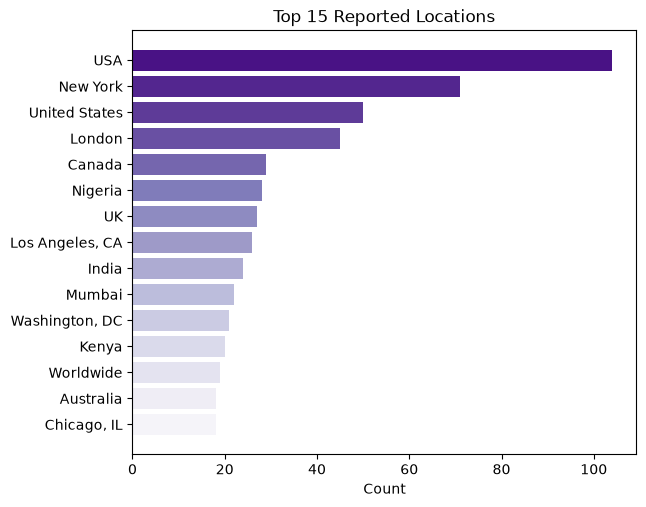

In [22]:
loc_counts = (
    df.loc[df["location"] != "unknown", "location"]
    .value_counts()
    .head(15)
    .sort_values()
)
plt.figure(figsize=(6.5, 5.5))
colors = sns.color_palette("Purples", n_colors=len(loc_counts))
plt.barh(loc_counts.index, loc_counts.values, color=colors)
plt.title("Top 15 Reported Locations")
plt.xlabel("Count")
plt.show()

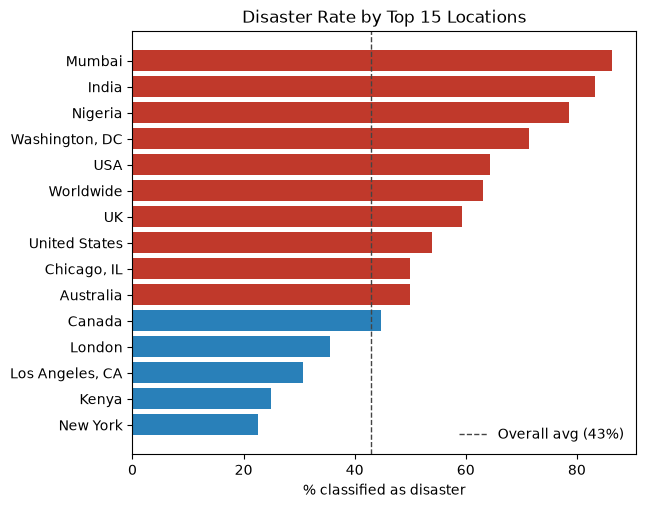

In [23]:
top15_locs = df.loc[df["location"] != "unknown", "location"].value_counts().head(15).index
loc_rate = (
    df[df["location"].isin(top15_locs)]
    .groupby("location")["target"]
    .mean()
    .mul(100)
    .sort_values()
)
plt.figure(figsize=(6.5, 5.5))
colors = [COLOR_DISASTER if v >= 50 else COLOR_NONDISASTER for v in loc_rate.values]
plt.barh(loc_rate.index, loc_rate.values, color=colors)
plt.axvline(df["target"].mean() * 100, color="#444444", linestyle="--", linewidth=1,
            label=f"Overall avg ({df['target'].mean()*100:.0f}%)")
plt.title("Disaster Rate by Top 15 Locations")
plt.xlabel("% classified as disaster")
plt.legend(frameon=False, loc="lower right")
plt.show()

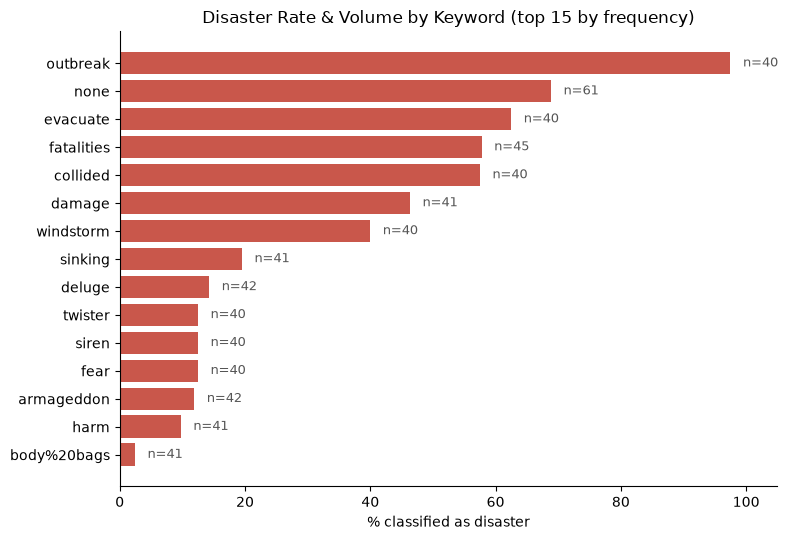

In [24]:
top15_kw_all = df["keyword"].value_counts().head(15).index
kw_stats = (
    df[df["keyword"].isin(top15_kw_all)]
    .groupby("keyword")
    .agg(disaster_rate=("target", "mean"), volume=("target", "size"))
)
kw_stats["disaster_rate"] *= 100
kw_stats = kw_stats.sort_values("disaster_rate")
 
fig, ax1 = plt.subplots(figsize=(8, 5.5))
bars = ax1.barh(kw_stats.index, kw_stats["disaster_rate"], color=COLOR_DISASTER, alpha=0.85)
ax1.set_xlabel("% classified as disaster")
ax1.set_title("Disaster Rate & Volume by Keyword (top 15 by frequency)")
ax1.set_xlim(0, 105)
for bar, vol in zip(bars, kw_stats["volume"]):
    ax1.text(bar.get_width() + 2, bar.get_y() + bar.get_height() / 2,
              f"n={vol}", va="center", fontsize=9, color="#555555")
sns.despine(ax=ax1)
plt.tight_layout()
plt.show()

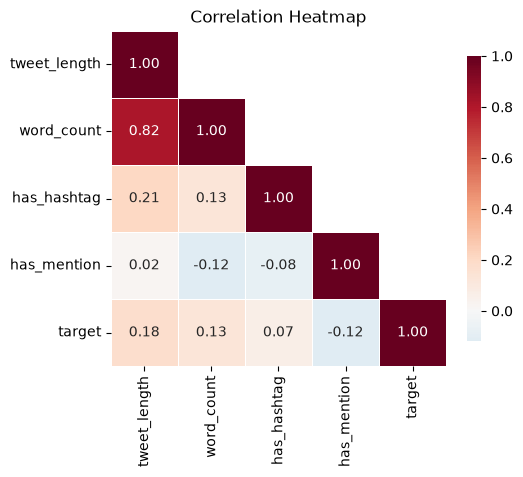

In [25]:
numeric_cols = ["tweet_length", "word_count", "has_hashtag", "has_mention", "target"]
corr = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
plt.figure(figsize=(5.5, 4.8))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            square=True, linewidths=0.5, linecolor="white",
            cbar_kws={"shrink": 0.8})
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [26]:
df

,id,keyword,location,text,target,clean_text,tokens,tokens_str,tweet_length,word_count,has_hashtag,has_mention
0,1,none,unknown,Our Deeds are the Reason of this #earthquake M...,1,our deeds are the reason of this earthquake ma...,"[deed, reason, earthquake, may, allah, forgive...",deed reason earthquake may allah forgive u,69,7,1,0
1,4,none,unknown,Forest fire near La Ronge Sask. Canada,1,forest fire near la ronge sask canada,"[forest, fire, near, la, ronge, sask, canada]",forest fire near la ronge sask canada,38,7,0,0
2,5,none,unknown,All residents asked to 'shelter in place' are ...,1,all residents asked to shelter in place are be...,"[resident, asked, shelter, place, notified, of...",resident asked shelter place notified officer ...,133,11,0,0
3,6,none,unknown,"13,000 people receive #wildfires evacuation or...",1,people receive wildfires evacuation orders in ...,"[people, receive, wildfire, evacuation, order,...",people receive wildfire evacuation order calif...,65,6,1,0
4,7,none,unknown,Just got sent this photo from Ruby #Alaska as ...,1,just got sent this photo from ruby alaska as s...,"[got, sent, photo, ruby, alaska, smoke, wildfi...",got sent photo ruby alaska smoke wildfire pour...,88,9,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
7608,10869,none,unknown,Two giant cranes holding a bridge collapse int...,1,two giant cranes holding a bridge collapse int...,"[two, giant, crane, holding, bridge, collapse,...",two giant crane holding bridge collapse nearby...,83,8,0,0
7609,10870,none,unknown,@aria_ahrary @TheTawniest The out of control w...,1,the out of control wild fires in california ev...,"[control, wild, fire, california, even, northe...",control wild fire california even northern par...,125,9,0,1
7610,10871,none,unknown,M1.94 [01:04 UTC]?5km S of Volcano Hawaii. htt...,1,m utc km s of volcano hawaii,"[utc, km, volcano, hawaii]",utc km volcano hawaii,65,4,0,0
7611,10872,none,unknown,Police investigating after an e-bike collided ...,1,police investigating after an ebike collided w...,"[police, investigating, ebike, collided, car, ...",police investigating ebike collided car little...,137,14,0,0


In [27]:
X = df["tokens_str"]
y = df["target"]
 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
 
print("\nTrain size:", X_train.shape[0], " Test size:", X_test.shape[0])
print("Train class balance:\n", y_train.value_counts(normalize=True))
print("Test class balance:\n", y_test.value_counts(normalize=True))


Train size: 6090  Test size: 1523
Train class balance:
 target
0    0.570279
1    0.429721
Name: proportion, dtype: float64
Test class balance:
 target
0    0.570584
1    0.429416
Name: proportion, dtype: float64


In [28]:
df.to_csv("twitter_disaster_cleaned.csv", index=False)
train_df = pd.DataFrame({"text": X_train, "label": y_train})
test_df = pd.DataFrame({"text": X_test, "label": y_test})
train_df.to_csv("train.csv", index=False)
test_df.to_csv("test.csv", index=False)

 # TF-IDF vectorization

In [29]:
train_idx = train_df.index
test_idx = test_df.index
 
X_train_text = train_df["text"]
X_test_text = test_df["text"]
y_train = train_df["label"]
y_test = test_df["label"]

In [30]:
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),   # unigrams + bigrams
    min_df=2,
    max_df=0.9,
)
X_train_tfidf = tfidf.fit_transform(X_train_text)
X_test_tfidf = tfidf.transform(X_test_text)
 
print("TF-IDF train shape:", X_train_tfidf.shape)
print("TF-IDF test shape:", X_test_tfidf.shape)

TF-IDF train shape: (6090, 5000)
TF-IDF test shape: (1523, 5000)


In [31]:
analyzer = SentimentIntensityAnalyzer()
 
 
def build_features(text_series: pd.Series) -> pd.DataFrame:
    feats = pd.DataFrame()
    feats["tweet_length"] = text_series.str.len()
    feats["word_count"] = text_series.str.split().apply(len)
    feats["has_hashtag"] = text_series.str.contains(r"#\w+", regex=True).astype(int)
    feats["has_mention"] = text_series.str.contains(r"@\w+", regex=True).astype(int)
    feats["sentiment"] = text_series.apply(
        lambda t: analyzer.polarity_scores(t)["compound"]
    )
    return feats

In [32]:
train_extra = build_features(X_train_text)
test_extra = build_features(X_test_text)
 
scaler = MinMaxScaler()
train_extra_scaled = scaler.fit_transform(train_extra)
test_extra_scaled = scaler.transform(test_extra)

# Combine TF-IDF (sparse) with extra numeric features (dense -> sparse)

In [33]:
X_train = hstack([X_train_tfidf, csr_matrix(train_extra_scaled)]).tocsr()
X_test = hstack([X_test_tfidf, csr_matrix(test_extra_scaled)]).tocsr()
 
print("Final train feature matrix:", X_train.shape)
print("Final test feature matrix:", X_test.shape)

Final train feature matrix: (6090, 5005)
Final test feature matrix: (1523, 5005)


# Train the model

In [34]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Multinomial Naive Bayes": MultinomialNB(),
    "Linear SVM": LinearSVC(random_state=42),
}
 
cv_results = {}
for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring="f1")
    cv_results[name] = scores
    print(f"{name}: F1 = {scores.mean():.4f} (+/- {scores.std():.4f})")
 
best_model_name = max(cv_results, key=lambda k: cv_results[k].mean())
print(f"\nBest candidate by CV F1: {best_model_name}")

Logistic Regression: F1 = 0.7360 (+/- 0.0143)
Multinomial Naive Bayes: F1 = 0.7251 (+/- 0.0174)
Linear SVM: F1 = 0.7224 (+/- 0.0122)

Best candidate by CV F1: Logistic Regression


Linear SVM: F1 = 0.7238 (+/- 0.0116)

Best candidate by CV F1: Logistic Regression


# Hyperparameter tuning with GridSearchCV

In [35]:
param_grids = {
    "Logistic Regression": {
        "C": [0.01, 0.1, 1, 10],
        "penalty": ["l2"],
        "solver": ["liblinear"],
    },
    "Multinomial Naive Bayes": {
        "alpha": [0.1, 0.5, 1.0, 2.0],
    },
    "Linear SVM": {
        "C": [0.01, 0.1, 1, 10],
    },
}
 
base_model = models[best_model_name]
grid = GridSearchCV(
    base_model,
    param_grids[best_model_name],
    cv=5,
    scoring="f1",
    n_jobs=-1,
)
grid.fit(X_train, y_train)
 
print(f"\nBest params for {best_model_name}: {grid.best_params_}")
print(f"Best CV F1: {grid.best_score_:.4f}")
 
best_model = grid.best_estimator_
 


Best params for Logistic Regression: {'C': 1, 'penalty': 'l2', 'solver': 'liblinear'}
Best CV F1: 0.7361


C:\Users\vincy\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


In [36]:
test_preds = best_model.predict(X_test)
print("\nHoldout test accuracy:", accuracy_score(y_test, test_preds))
print("Holdout test F1:", f1_score(y_test, test_preds))


Holdout test accuracy: 0.804333552199606
Holdout test F1: 0.7577235772357723


## Model Evaluation
Confusion matrix, classification report, and ROC curve for the tuned model on the held-out test set.

In [37]:
y_pred = best_model.predict(X_test)

if hasattr(best_model, "predict_proba"):
    y_scores = best_model.predict_proba(X_test)[:, 1]
else:
    y_scores = best_model.decision_function(X_test)

print(classification_report(y_test, y_pred, target_names=["Non-disaster", "Disaster"]))


              precision    recall  f1-score   support

Non-disaster       0.80      0.87      0.84       869
    Disaster       0.81      0.71      0.76       654

    accuracy                           0.80      1523
   macro avg       0.81      0.79      0.80      1523
weighted avg       0.80      0.80      0.80      1523



<Figure size 550x500 with 0 Axes>

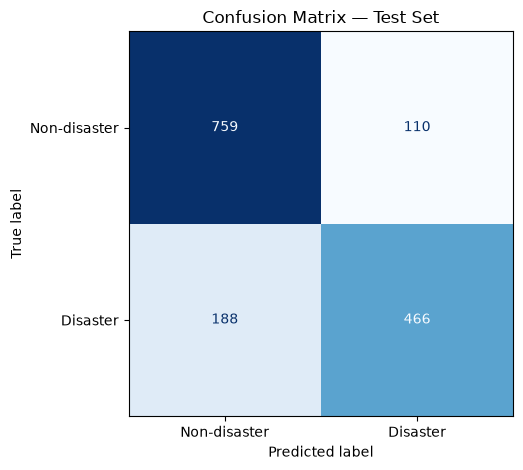

In [38]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5.5, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Non-disaster", "Disaster"])
disp.plot(cmap="Blues", colorbar=False, values_format="d")
plt.title("Confusion Matrix — Test Set")
plt.grid(False)
plt.tight_layout()
plt.show()


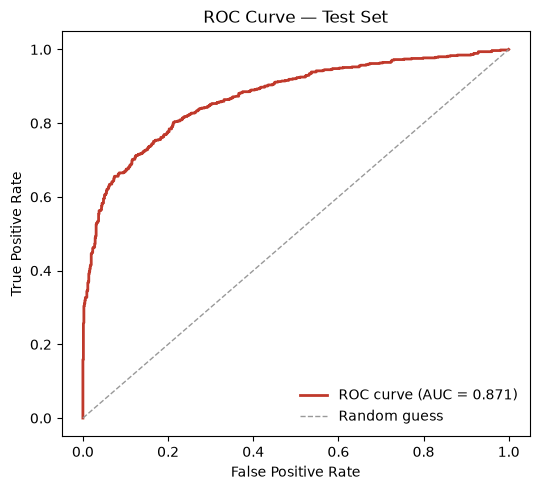

In [39]:
fpr, tpr, _ = roc_curve(y_test, y_scores)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(5.5, 5))
plt.plot(fpr, tpr, color="#c0392b", linewidth=2, label=f"ROC curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], color="#999999", linestyle="--", linewidth=1, label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Test Set")
plt.legend(frameon=False, loc="lower right")
plt.tight_layout()
plt.show()


## Actual vs Predicted Comparison
Compare true labels against the model's predictions on the test set — both as an aggregate count comparison and as a row-level sample table.

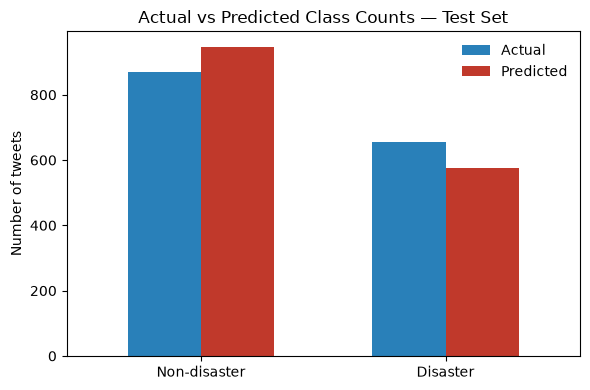

In [40]:
# Aggregate: actual class counts vs predicted class counts
comparison_df = pd.DataFrame({
    "Actual": y_test.value_counts().sort_index(),
    "Predicted": pd.Series(y_pred).value_counts().sort_index(),
})
comparison_df.index = ["Non-disaster", "Disaster"]

comparison_df.plot(kind="bar", color=["#2980b9", "#c0392b"], figsize=(6, 4), width=0.6)
plt.title("Actual vs Predicted Class Counts — Test Set")
plt.ylabel("Number of tweets")
plt.xticks(rotation=0)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()


In [41]:
# Row-level sample: actual label vs predicted label vs predicted probability,
# for a random sample of test tweets
results_df = pd.DataFrame({
    "text": X_test_text.values,
    "actual": y_test.map({0: "Non-disaster", 1: "Disaster"}).values,
    "predicted": pd.Series(y_pred).map({0: "Non-disaster", 1: "Disaster"}).values,
    "disaster_probability": y_scores,
})
results_df["correct"] = results_df["actual"] == results_df["predicted"]

display(results_df.sample(15, random_state=1).reset_index(drop=True))


,text,actual,predicted,disaster_probability,correct
0,miss josie cause wan na smoke splifs go taco bell,Non-disaster,Non-disaster,0.199486,True
1,wouldnt turn sandstorm riot gave good answer i...,Non-disaster,Non-disaster,0.282686,True
2,strict liability context airplane accident pil...,Disaster,Disaster,0.675073,True
3,sneak america u spoiled natural disaster humbl...,Disaster,Non-disaster,0.479193,False
4,here may caused metro train derail downtown dc,Disaster,Disaster,0.662931,True
5,feel pain survivor look back period absurd hum...,Disaster,Disaster,0.601288,True
6,heard day ago driving near crashed car laughin...,Non-disaster,Non-disaster,0.348703,True
7,reddits new content policy go effect many horr...,Non-disaster,Non-disaster,0.204135,True
8,really cant believe skipping republican meltdo...,Non-disaster,Non-disaster,0.196859,True
9,hand glass water sit rescued tenno ive lived s...,Non-disaster,Non-disaster,0.238897,True


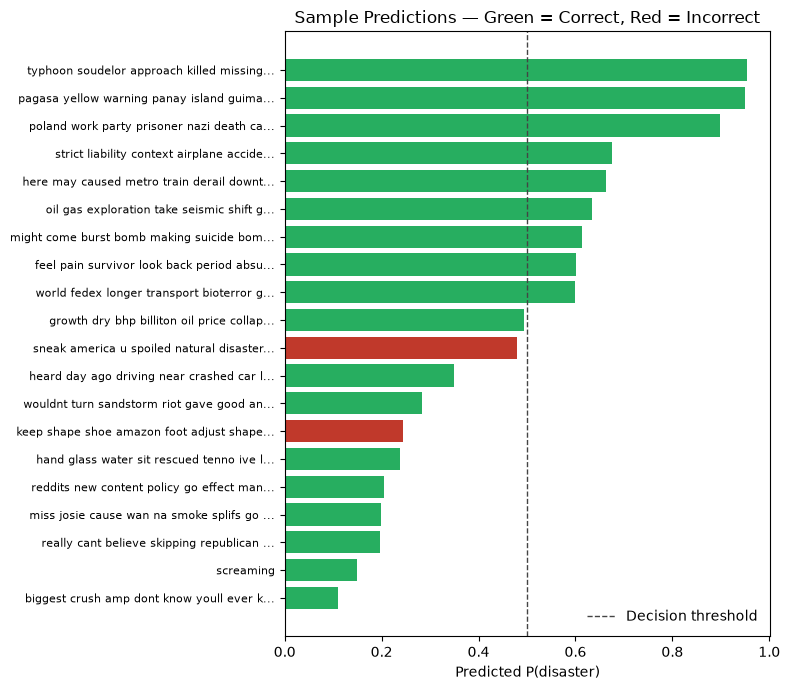

In [42]:
# Visualize a sample of test tweets: actual vs predicted, colored by correctness
sample = results_df.sample(20, random_state=1).reset_index(drop=True)
sample = sample.sort_values("disaster_probability")

colors = sample["correct"].map({True: "#27ae60", False: "#c0392b"})
plt.figure(figsize=(8, 7))
plt.barh(range(len(sample)), sample["disaster_probability"], color=colors)
plt.yticks(range(len(sample)),
           [f"{t[:40]}{'...' if len(t) > 40 else ''}" for t in sample["text"]], fontsize=8)
plt.axvline(0.5, color="#444444", linestyle="--", linewidth=1, label="Decision threshold")
plt.xlabel("Predicted P(disaster)")
plt.title("Sample Predictions — Green = Correct, Red = Incorrect")
plt.legend(frameon=False, loc="lower right")
plt.tight_layout()
plt.show()


## Save the Trained Model
Persist the fitted vectorizer, scaler, and best model so they can be reloaded later without retraining.

In [43]:
joblib.dump(best_model, "final_model.pkl")
joblib.dump(tfidf, "final_tfidf_vectorizer.pkl")
joblib.dump(scaler, "final_feature_scaler.pkl")

print("Saved: final_model.pkl, final_tfidf_vectorizer.pkl, final_feature_scaler.pkl")


Saved: final_model.pkl, final_tfidf_vectorizer.pkl, final_feature_scaler.pkl


## Predict on Custom Input

In [44]:
def build_single_features(raw_text: str) -> pd.DataFrame:
    return pd.DataFrame([{
        "tweet_length": len(raw_text),
        "word_count": len(raw_text.split()),
        "has_hashtag": int(bool(re.search(r"#\w+", raw_text))),
        "has_mention": int(bool(re.search(r"@\w+", raw_text))),
        "sentiment": analyzer.polarity_scores(raw_text)["compound"],
    }])


def predict_tweet(raw_text: str) -> dict:
    """Clean, vectorize, and predict on a single piece of raw text."""
    cleaned = clean_text(raw_text)

    tfidf_feat = tfidf.transform([cleaned])
    extra_feat = scaler.transform(build_single_features(raw_text))
    X = hstack([tfidf_feat, csr_matrix(extra_feat)]).tocsr()

    pred = best_model.predict(X)[0]

    if hasattr(best_model, "predict_proba"):
        disaster_prob = best_model.predict_proba(X)[0][1]
    else:
        score = best_model.decision_function(X)[0]
        disaster_prob = 1 / (1 + np.exp(-score))

    return {
        "text": raw_text,
        "prediction": "Disaster" if pred == 1 else "Non-disaster",
        "disaster_probability": float(disaster_prob),
    }


{'text': 'Massive wildfire spreading fast near the highway, evacuations underway', 'prediction': 'Disaster', 'disaster_probability': 0.8095875030826764}


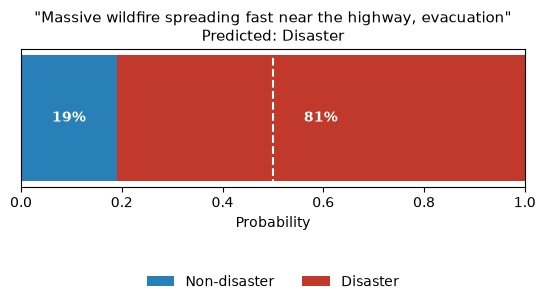

In [45]:
# --- Try your own text here ---
custom_text = "Massive wildfire spreading fast near the highway, evacuations underway"

result = predict_tweet(custom_text)
print(result)

disaster_prob = result["disaster_probability"]
nondisaster_prob = 1 - disaster_prob

fig, ax = plt.subplots(figsize=(6.5, 2.6))
ax.barh(["Prediction"], [nondisaster_prob], color="#2980b9", label="Non-disaster", height=0.5)
ax.barh(["Prediction"], [disaster_prob], left=[nondisaster_prob], color="#c0392b", label="Disaster", height=0.5)
ax.set_xlim(0, 1)
ax.set_xlabel("Probability")
ax.set_yticks([])
ax.axvline(0.5, color="white", linewidth=1.5, linestyle="--")
ax.text(nondisaster_prob / 2, 0, f"{nondisaster_prob:.0%}", va="center", ha="center", color="white", fontweight="bold")
ax.text(nondisaster_prob + disaster_prob / 2, 0, f"{disaster_prob:.0%}", va="center", ha="center", color="white", fontweight="bold")
ax.set_title(f'"{custom_text[:60]}"\nPredicted: {result["prediction"]}', fontsize=11)
ax.legend(frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.55), ncol=2)
plt.subplots_adjust(bottom=0.35)
plt.show()


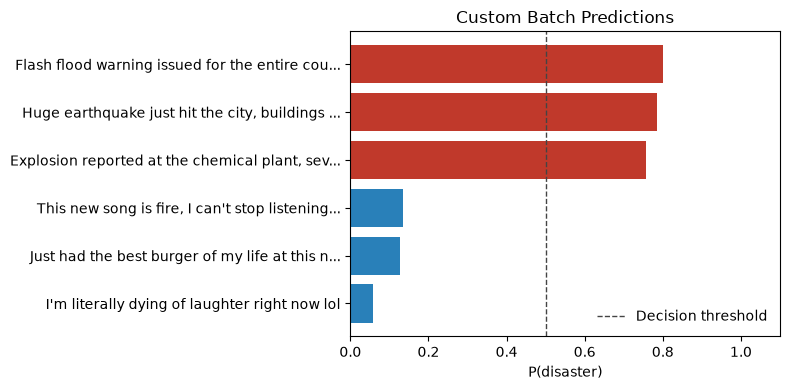

,text,prediction,disaster_probability
3,I'm literally dying of laughter right now lol,Non-disaster,0.058083
5,Just had the best burger of my life at this ne...,Non-disaster,0.127117
1,"This new song is fire, I can't stop listening ...",Non-disaster,0.135856
4,"Explosion reported at the chemical plant, seve...",Disaster,0.756408
0,"Huge earthquake just hit the city, buildings c...",Disaster,0.786344
2,Flash flood warning issued for the entire coun...,Disaster,0.800574


In [46]:
# --- Batch of custom texts, compared side by side ---
example_tweets = [
    "Huge earthquake just hit the city, buildings collapsing everywhere",
    "This new song is fire, I can't stop listening to it",
    "Flash flood warning issued for the entire county tonight",
    "I'm literally dying of laughter right now lol",
    "Explosion reported at the chemical plant, several injured",
    "Just had the best burger of my life at this new restaurant",
]

batch_results = pd.DataFrame([predict_tweet(t) for t in example_tweets])
batch_results = batch_results.sort_values("disaster_probability")

colors = batch_results["disaster_probability"].apply(lambda p: "#c0392b" if p >= 0.5 else "#2980b9")
labels = [t[:45] + ("..." if len(t) > 45 else "") for t in batch_results["text"]]

plt.figure(figsize=(8, 4))
plt.barh(labels, batch_results["disaster_probability"], color=colors)
plt.axvline(0.5, color="#444444", linestyle="--", linewidth=1, label="Decision threshold")
plt.xlim(0, 1.1)
plt.xlabel("P(disaster)")
plt.title("Custom Batch Predictions")
plt.legend(frameon=False, loc="lower right")
plt.tight_layout()
plt.show()

display(batch_results)
